#### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "..")

from src.data.loader import download_prices, format_prices
from src.evaluation.walk_forward import run_evaluation

sns.set_style("whitegrid")
SEED = 40304451
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 150


## Targets:

We're trying to test for 11 yfinance ETFs shown below, for horizon = 5, and step = 10.

In [2]:
TICKERS = [
    "XLK",  # Technology
    "XLP",  # Consumer Staples
    "XLV",  # Health Care
    "XLF",  # Financials
    "XLE",  # Energy
    "XLI",  # Industrials
    "XLY",  # Consumer Discretionary
    "XLU",  # Utilities
    "XLB",  # Materials
    "XLRE", # Real Estate
    "XLC",  # Communication Services
]

DATE_DOWNLOAD_START = "2010-01-01"
DATE_DOWNLOAD_END = "2024-12-31"

DATE_EVAL_START = "2015-01-01"
DATE_EVAL_END = "2019-12-31"

HORIZON = 5
STEP = 10

print(f"Tickers: {TICKERS}")
print(f"Data date range: {DATE_DOWNLOAD_START} to {DATE_DOWNLOAD_END}")
print(f"Eval: {DATE_EVAL_START} to {DATE_EVAL_END}")
print(f"Horizon: {HORIZON} days")
print(f"Step: {STEP} days")

Tickers: ['XLK', 'XLP', 'XLV', 'XLF', 'XLE', 'XLI', 'XLY', 'XLU', 'XLB', 'XLRE', 'XLC']
Data date range: 2010-01-01 to 2024-12-31
Eval: 2015-01-01 to 2019-12-31
Horizon: 5 days
Step: 10 days


## Baseline Configurations

In [3]:
configs = {
    "lags_only": {
        "n_lags": 5,
        "parkinson_vol_windows": (),
        "alpha_grid": (0.01, 0.1, 1.0, 10.0)
    },
    "lags_and_p_vol": {
        "n_lags": 5,
        "parkinson_vol_windows": (5, 10),
        "alpha_grid": (0.01, 0.1, 1.0, 10.0)
    }
}

print(f"{len(configs)} configs defined: {list(configs.keys())}")

2 configs defined: ['lags_only', 'lags_and_p_vol']


## Download yfinance Data

In [4]:
raw_prices = download_prices(TICKERS, start=DATE_DOWNLOAD_START, end=DATE_DOWNLOAD_END)
prices_df  = format_prices(raw_prices)

print(f"\nDataFrame shape : {prices_df.shape}")
print(f"Tickers present : {prices_df['ticker'].unique().tolist()}")
prices_df.head()

XLK: 3773 rows downloaded
XLP: 3773 rows downloaded
XLV: 3773 rows downloaded
XLF: 3773 rows downloaded
XLE: 3773 rows downloaded
XLI: 3773 rows downloaded
XLY: 3773 rows downloaded
XLU: 3773 rows downloaded
XLB: 3773 rows downloaded
XLRE: 2322 rows downloaded
XLC: 1644 rows downloaded

Total rows before cleaning: 37923

Missing values per column after formatting:
Open      0
High      0
Low       0
Close     0
Volume    5
dtype: int64

DataFrame shape : (37923, 10)
Tickers present : ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains,ticker
date,,,,,,,,,,
2010-01-04,16.790001,17.010000,16.725000,17.010000,12.016511,15135000.0,0.0,0.0,0.0,XLB
2010-01-05,17.040001,17.090000,16.905001,17.065001,12.055367,17678400.0,0.0,0.0,0.0,XLB
2010-01-06,17.070000,17.415001,17.040001,17.355000,12.260237,16184000.0,0.0,0.0,0.0,XLB
2010-01-07,17.270000,17.290001,17.080000,17.219999,12.164867,11514600.0,0.0,0.0,0.0,XLB
2010-01-08,17.180000,17.459999,17.139999,17.459999,12.334411,9284800.0,0.0,0.0,0.0,XLB


## Walk-Forward Evaluation

In [5]:
baseline_results = run_evaluation(
    configs=configs,
    prices_df=prices_df,
    tickers=TICKERS,
    date_start=DATE_EVAL_START,
    date_end=DATE_EVAL_END,
    horizon=HORIZON,
    step=STEP,
    verbose=True,
    return_predictions=True
)

print(f"\nResults shape: {baseline_results.shape}")
baseline_results.head()


____________________________________________________________
Config: lags_only
Params: {'n_lags': 5, 'parkinson_vol_windows': (), 'alpha_grid': (0.01, 0.1, 1.0, 10.0)}

XLK: 3773 rows, 2010-01-04 to 2024-12-30
Forward log return (h=5): 1253 valid targets, 5 NaN (expected 5 at end)
Walk-forward: 1253 test dates, step=10, horizon=5
Log returns computed: 0 valid observations, 0 NaN
Features constructed: 5 columns, 0 rows after dropna
Fallback dummy fitted with constant=0.000000
Log returns computed: 9 valid observations, 1 NaN
Features constructed: 5 columns, 4 rows after dropna
Log returns computed: 9 valid observations, 1 NaN
Features constructed: 5 columns, 4 rows after dropna
Insufficient training data: 4 rows (min=200)
Fallback dummy fitted with constant=0.002134
Log returns computed: 19 valid observations, 1 NaN
Features constructed: 5 columns, 14 rows after dropna
Log returns computed: 19 valid observations, 1 NaN
Features constructed: 5 columns, 14 rows after dropna
Insufficient 

,config,ticker,date,y_true,y_pred,ic,p_value,diracc,mae,rmse
0,lags_only,XLK,2015-01-12,-0.001227,0.000000,-0.013504,0.633794,0.576584,0.017068,0.023026
1,lags_only,XLK,2015-01-13,0.001227,0.000000,-0.013504,0.633794,0.576584,0.017068,0.023026
2,lags_only,XLK,2015-01-14,0.023180,0.000000,-0.013504,0.633794,0.576584,0.017068,0.023026
3,lags_only,XLK,2015-01-15,0.035858,0.000000,-0.013504,0.633794,0.576584,0.017068,0.023026
4,lags_only,XLK,2015-01-16,0.022043,0.002134,-0.013504,0.633794,0.576584,0.017068,0.023026


## Results Summary:

In [6]:
summary = (
    baseline_results
    .groupby(["config", "ticker"])[["ic", "diracc", "mae", "rmse"]]
    .mean()
    .round(4)
)

print("Per-ticker results:")
print(summary.to_string())

print("\nMean across tickers:")
print(summary.groupby("config").mean().round(4).to_string())

Per-ticker results:
                           ic  diracc     mae    rmse
config         ticker                                
lags_and_p_vol XLB     0.0056  0.4677  0.0177  0.0240
               XLC    -0.0128  0.4084  0.0195  0.0254
               XLE     0.0228  0.4988  0.0226  0.0301
               XLF    -0.0855  0.5044  0.0175  0.0240
               XLI     0.0054  0.5108  0.0162  0.0220
               XLK    -0.0100  0.5658  0.0171  0.0230
               XLP    -0.0094  0.4996  0.0118  0.0163
               XLRE    0.0259  0.5189  0.0153  0.0203
               XLU    -0.0418  0.4924  0.0148  0.0192
               XLV    -0.0058  0.5116  0.0156  0.0209
               XLY     0.0024  0.5395  0.0151  0.0208
lags_only      XLB    -0.0842  0.5180  0.0175  0.0240
               XLC     0.0222  0.4495  0.0193  0.0253
               XLE    -0.0746  0.4635  0.0226  0.0301
               XLF    -0.0642  0.5140  0.0174  0.0240
               XLI    -0.0606  0.5357  0.0161  0.0219
        

## Visualisations

## IC by Ticker and Config

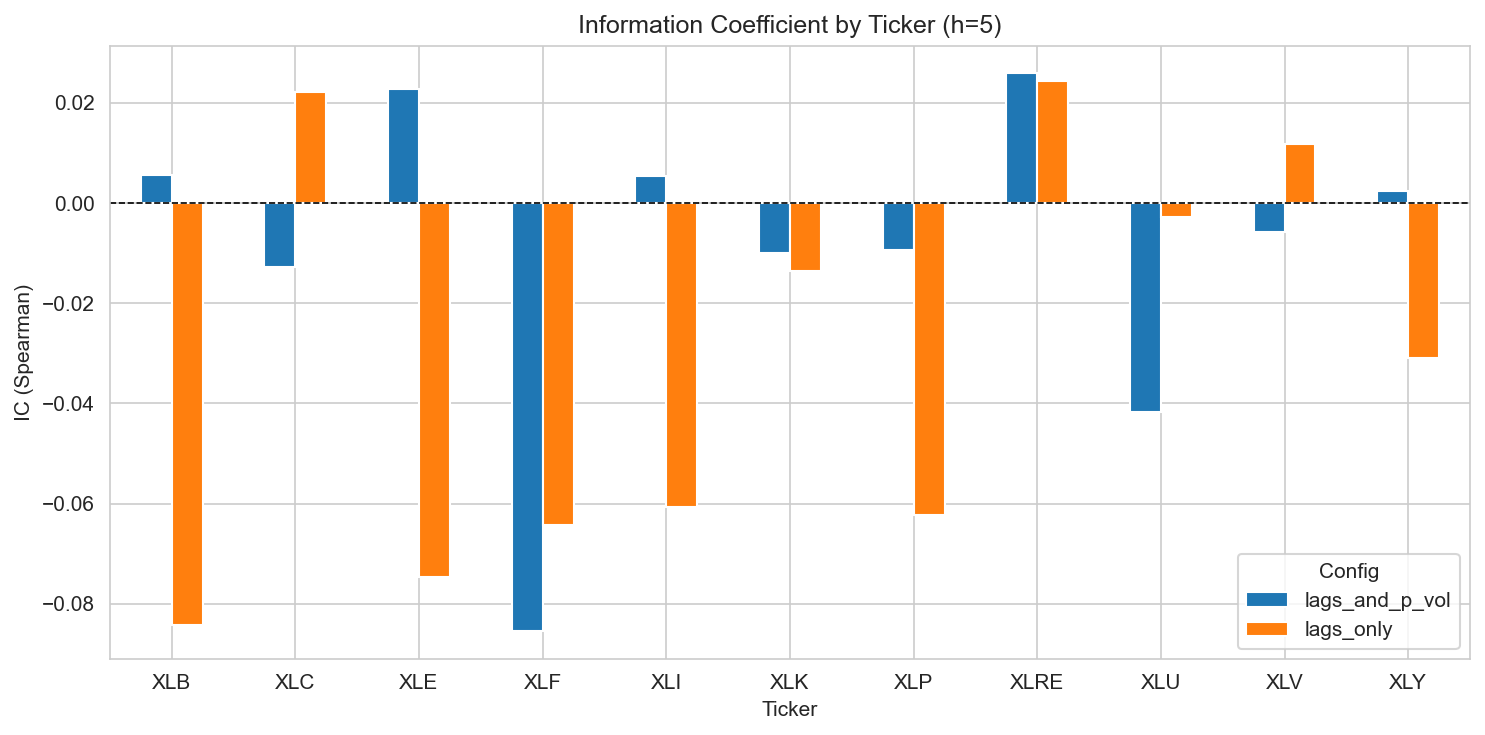

In [7]:
ic_summary = summary["ic"].unstack(level="config")

fig, ax = plt.subplots(figsize=(10, 5))
ic_summary.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Information Coefficient by Ticker (h={HORIZON})")
ax.set_xlabel("Ticker")
ax.set_ylabel("IC (Spearman)")
ax.legend(title="Config")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/figures/ic_by_ticker.png", dpi=150)
plt.show()

### Predicted vs Actual Returns (One Ticker)

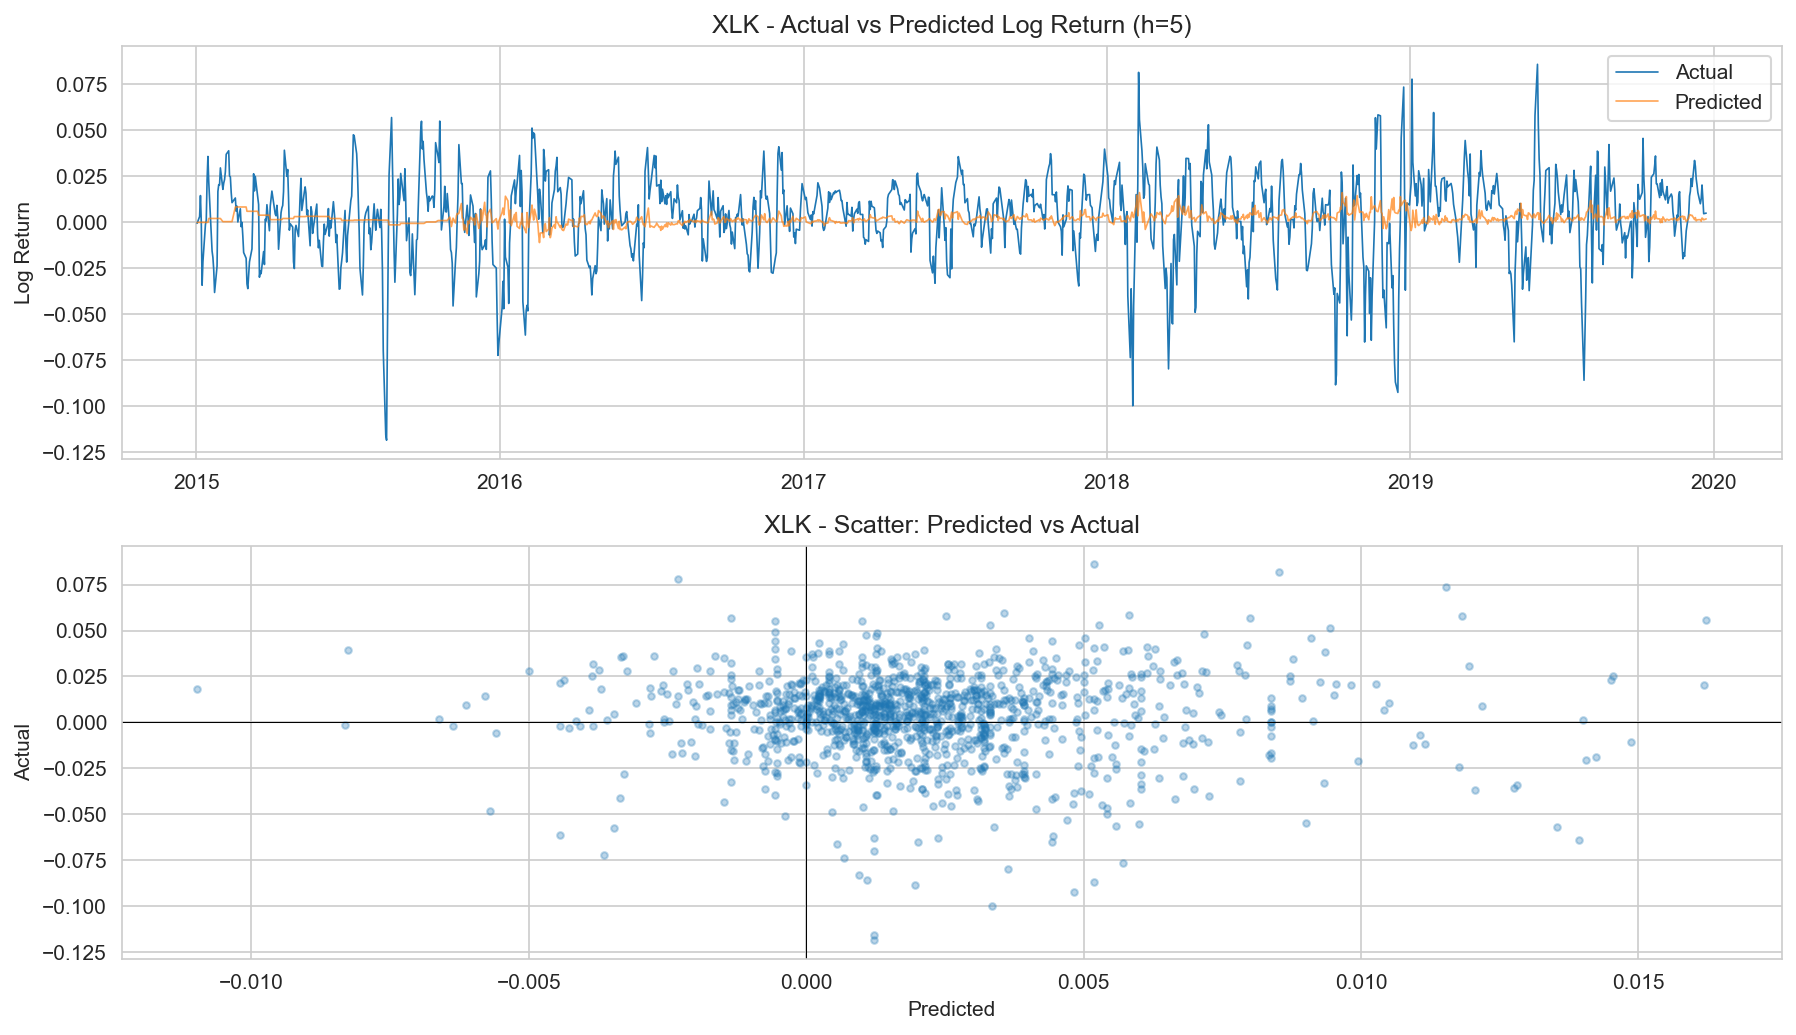

In [ ]:
plot_ticker = TICKERS[0]
plot_config = "lags_and_p_vol"

subset = baseline_results[
    (baseline_results["ticker"] == plot_ticker) &
    (baseline_results["config"] == plot_config)
].set_index("date").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(subset.index, subset["y_true"], label="Actual", linewidth=0.8)
axes[0].plot(subset.index, subset["y_pred"], label="Predicted", linewidth=0.8, alpha=0.7)
axes[0].set_title(f"{plot_ticker} Actual vs Predicted Log Return (h={HORIZON})")
axes[0].set_ylabel("Log Return")
axes[0].legend()

axes[1].scatter(subset["y_pred"], subset["y_true"], alpha=0.3, s=10)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"{plot_ticker} Scatter: Predicted vs Actual")

plt.tight_layout()
plt.savefig(f"../results/figures/pred_vs_actual_{plot_ticker}.png", dpi=150)
plt.show()

In [9]:
print(subset.index.min())
print(subset.index.max())
print(subset["y_true"].describe())

2015-01-02 00:00:00
2019-12-23 00:00:00
count    1253.000000
mean        0.003230
std         0.022793
min        -0.118431
25%        -0.007464
50%         0.005830
75%         0.016700
max         0.085961
Name: y_true, dtype: float64
